# Trabajo Práctico Nro. 2
## Machine Learning 2.
### Ejercicio 1.
Alumnos:
  - Crenna, Giuliano.
  - Sancho Almenar, Mariano.
  - Pace, Bruno.

# Configuración del entorno

In [1]:
!export LD_LIBRARY_PATH=/usr/local/cuda/lib64:$LD_LIBRARY_PATH

In [2]:
# Standard library imports
import os
import pathlib
import urllib.request
import zipfile
import shutil
from pathlib import Path

# Third-party imports
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from IPython import display
import librosa

# TensorFlow specific imports
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import classification_report

# Set the seed value for experiment reproducibility
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

2025-06-29 21:49:19.342776: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-29 21:49:19.781301: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751233759.991518    1783 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751233760.036922    1783 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751233760.465962    1783 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        print(e)

1 Physical GPUs, 1 Logical GPUs


I0000 00:00:1751233767.972359    1783 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


# Carga del dataset

Se optó por extraer el datase desde el repositorio de github. Este contiene 3000 audios en lugar de 2500. Se cambió el uso del load directo de tensorflow-datasets.

In [4]:
DATASET_URL: str = "https://github.com/Jakobovski/free-spoken-digit-dataset/archive/refs/heads/master.zip"
DATASET_PATH: str = 'data/spoken_digits'
RAW_DATA_PATH: str = os.path.join(DATASET_PATH, 'recordings')
ZIP_FILE: str = 'spoken_digits.zip'

data_dir = pathlib.Path(DATASET_PATH)
data_dir.mkdir(parents=True, exist_ok=True)

if not os.path.exists(RAW_DATA_PATH):
    print("Downloading the Spoken Digit dataset...")
    urllib.request.urlretrieve(DATASET_URL, ZIP_FILE)

    with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
        zip_ref.extractall(DATASET_PATH)

    extracted_folder = os.path.join(DATASET_PATH, 'free-spoken-digit-dataset-master', 'recordings')
    shutil.move(extracted_folder, DATASET_PATH)

    os.remove(ZIP_FILE)
    shutil.rmtree(os.path.join(DATASET_PATH, 'free-spoken-digit-dataset-master'))
    print("Descarga y extracción completa")
else:
    print("El dataset ya existe.")

El dataset ya existe.


In [5]:
def organize_fsdd_dataset(raw_data_path: str, organized_data_path: str) -> None:
    """Reordena los FSDD en carpetas de clase."""

    Path(organized_data_path).mkdir(parents=True, exist_ok=True)

    for digit in range(10):
        os.makedirs(os.path.join(organized_data_path, str(digit)), exist_ok=True)

    for file_path in Path(raw_data_path).glob('*.wav'):
        digit = file_path.name.split('_')[0]  
        dest_path = os.path.join(organized_data_path, digit, file_path.name)
        shutil.move(str(file_path), dest_path)

    print(f"Dataset reorganizado en: {organized_data_path}")

RAW_DATA_PATH: str = 'data/spoken_digits/recordings'  
ORGANIZED_DATA_PATH: str = 'data/spoken_digits_organized'

organize_fsdd_dataset(RAW_DATA_PATH, ORGANIZED_DATA_PATH)

Dataset reorganizado en: data/spoken_digits_organized


Obtenemos datos de los audios para tomar decisiones posteriores. Nos interesa hacer una especie de normalización.

In [6]:
def analyze_sequence_lengths(data_path: str) -> dict[str, int]:
    """Analiza audios en samples y devuelve un diccionario con las estadísticas"""
    sequence_lengths = []

    # Find all WAV files recursively in class subdirectories
    wav_files = list(Path(data_path).rglob('*.wav'))

    if not wav_files:
        raise ValueError(f"No WAV files found in {data_path}")

    for file_path in wav_files:
        try:
            audio, _ = librosa.load(file_path, sr=None)  # Keep original sample rate
            sequence_lengths.append(len(audio))
        except Exception as e:
            print(f"Skipping {file_path.name}: {str(e)}")
            continue

    if not sequence_lengths:
        raise ValueError("No valid audio files processed")

    stats = {
        'min_samples': int(np.min(sequence_lengths)),
        'max_samples': int(np.max(sequence_lengths)),
        'mean_samples': int(np.mean(sequence_lengths)),
        'median_samples': int(np.median(sequence_lengths)),
        '95th_percentile': int(np.percentile(sequence_lengths, 95)),
        'total_files': len(sequence_lengths)
    }

    print("\nAudio Sequence Length (Samples)")
    print("-----------------------------")
    print(f"• Minimum: {stats['min_samples']:,} samples")
    print(f"• Maximum: {stats['max_samples']:,} samples")
    print(f"• Mean: {stats['mean_samples']:,} samples")
    print(f"• Median: {stats['median_samples']:,} samples")
    print(f"• 95th Percentile: {stats['95th_percentile']:,} samples")
    print(f"\nTotal files analyzed: {stats['total_files']}")
    return stats


stats = analyze_sequence_lengths('data/spoken_digits_organized')

stats['median_samples']


Audio Sequence Length (Samples)
-----------------------------
• Minimum: 1,148 samples
• Maximum: 18,262 samples
• Mean: 3,499 samples
• Median: 3,358 samples
• 95th Percentile: 5,299 samples

Total files analyzed: 3000


3358

# Preparación del dataset para las redes neuronales y EDA

Se crea el dataset teniendo en cuenta que la longitud de los audios es la media (promedio) del dataset.

In [7]:
# Parameters
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
SEED = 42
SEQUENCE_LENGTH = stats['median_samples']

# Create datasets
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=ORGANIZED_DATA_PATH,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    seed=SEED,
    output_sequence_length=SEQUENCE_LENGTH,
    subset='both',
    #labels='inferred',
    #label_mode='categorical'
)

# Get class names
label_names = np.array(train_ds.class_names)
print("\nLabel names:", label_names)

# Preview the dataset
print("\nDataset structure:")
for audio_batch, label_batch in train_ds.take(1):
    print("Audio batch shape:", audio_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("First label:", label_batch[0].numpy())

Found 3000 files belonging to 10 classes.
Using 2400 files for training.
Using 600 files for validation.

Label names: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']

Dataset structure:
Audio batch shape: (32, 3358, 1)
Label batch shape: (32,)
First label: 4


2025-06-29 21:49:39.617196: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
def squeeze(audio, labels):
  audio = tf.squeeze(audio, axis=-1)
  return audio, labels

train_ds = train_ds.map(squeeze, tf.data.AUTOTUNE)
val_ds = val_ds.map(squeeze, tf.data.AUTOTUNE)

In [9]:
for example_audio, example_labels in train_ds.take(1):
  print(example_audio.shape)
  print(example_labels.shape)

(32, 3358)
(32,)


2025-06-29 21:49:39.744840: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Podemos observar que no todos los números tienen el mismo patrón en la onda del sonido.

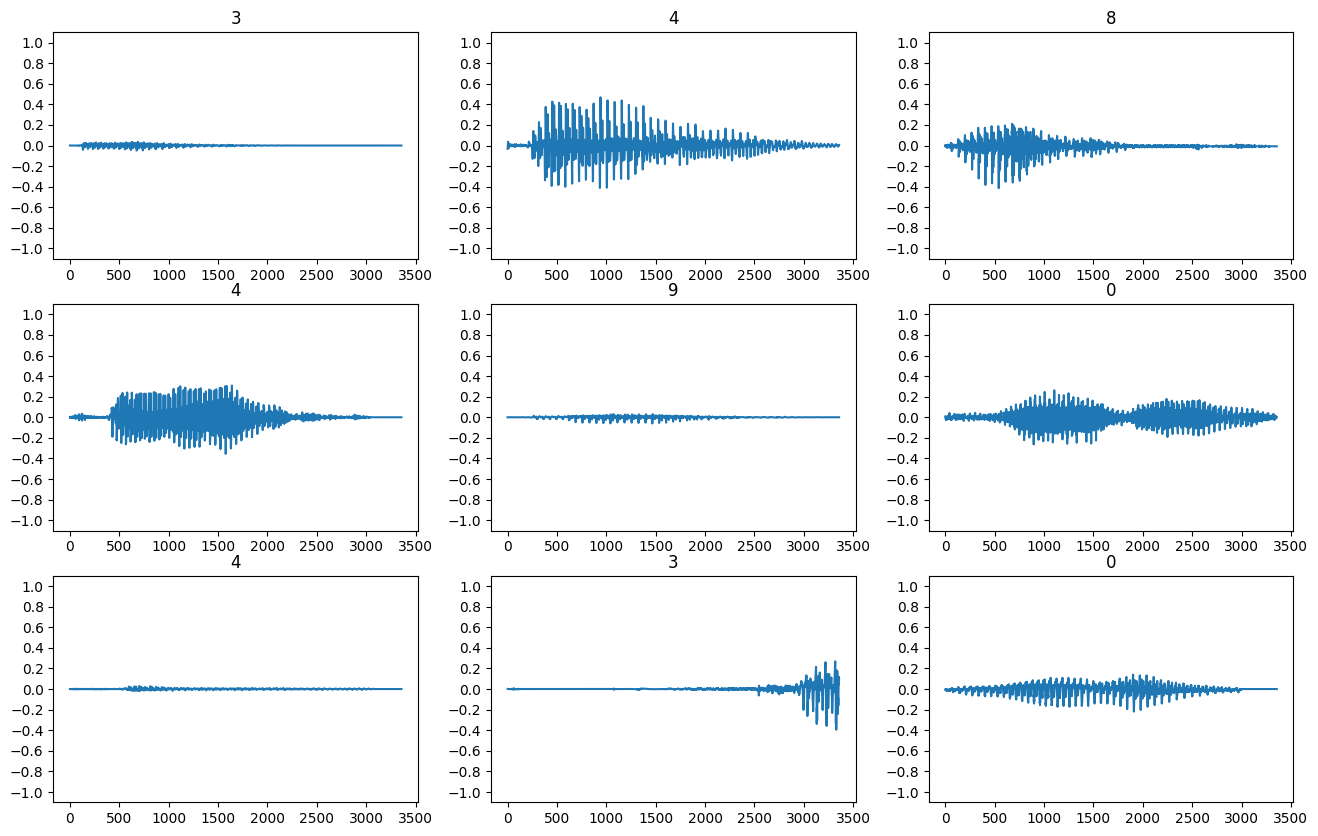

In [10]:
plt.figure(figsize=(16, 10))
rows = 3
cols = 3
n = rows * cols
for i in range(n):
  plt.subplot(rows, cols, i+1)
  audio_signal = example_audio[i]
  plt.plot(audio_signal)
  plt.title(label_names[example_labels[i]])
  plt.yticks(np.arange(-1.2, 1.2, 0.2))
  plt.ylim([-1.1, 1.1])

In [11]:
def get_spectrogram(waveform):
  # Convert the waveform to a spectrogram via a STFT.
  spectrogram = tf.signal.stft(
      waveform, frame_length=255, frame_step=128)
  # Obtain the magnitude of the STFT.
  spectrogram = tf.abs(spectrogram)
  # Add a `channels` dimension, so that the spectrogram can be used
  # as image-like input data with convolution layers (which expect
  # shape (`batch_size`, `height`, `width`, `channels`).
  spectrogram = spectrogram[..., tf.newaxis]
  return spectrogram

Extraemos tres audios para escucharlos.

In [12]:
for i in range(3):
  label = label_names[example_labels[i]]
  waveform = example_audio[i]
  spectrogram = get_spectrogram(waveform)

  print('Label:', label)
  print('Waveform shape:', waveform.shape)
  print('Spectrogram shape:', spectrogram.shape)
  print('Audio playback')
  display.display(display.Audio(waveform, rate=8000))

Label: 3
Waveform shape: (3358,)
Spectrogram shape: (25, 129, 1)
Audio playback


Label: 4
Waveform shape: (3358,)
Spectrogram shape: (25, 129, 1)
Audio playback


Label: 8
Waveform shape: (3358,)
Spectrogram shape: (25, 129, 1)
Audio playback


In [13]:
def plot_spectrogram(spectrogram, ax):
  if len(spectrogram.shape) > 2:
    assert len(spectrogram.shape) == 3
    spectrogram = np.squeeze(spectrogram, axis=-1)
  # Convert the frequencies to log scale and transpose, so that the time is
  # represented on the x-axis (columns).
  # Add an epsilon to avoid taking a log of zero.
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
  height = log_spec.shape[0]
  width = log_spec.shape[1]
  X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)

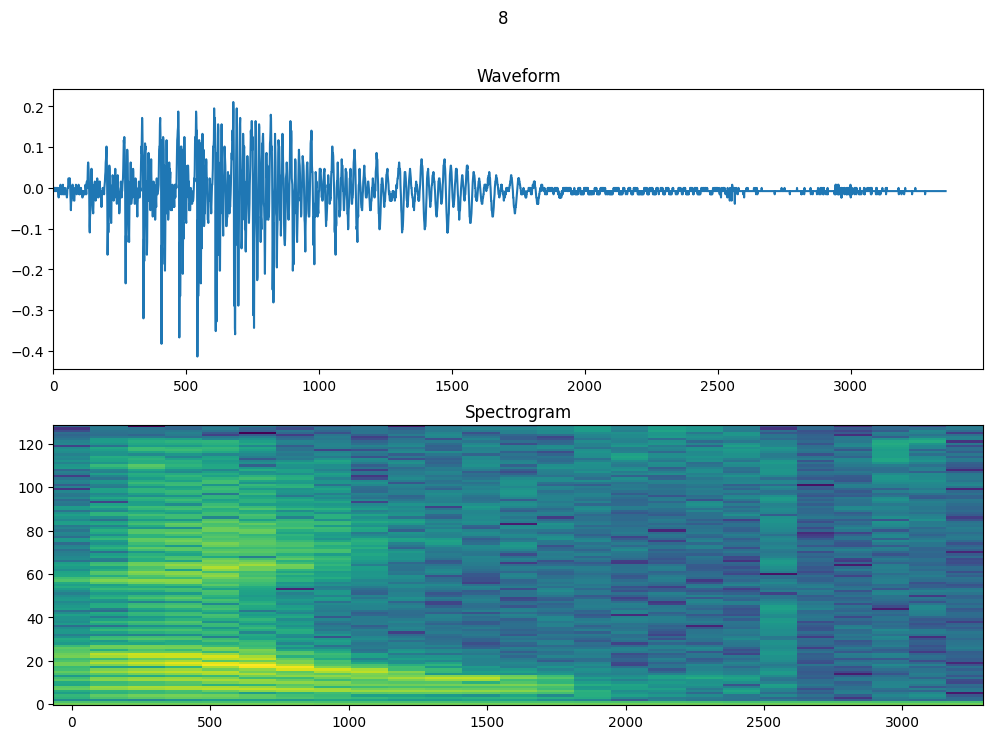

In [14]:
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, stats['mean_samples']])

plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.suptitle(label.title())
plt.show()

In [15]:
def make_spec_ds(ds):
  return ds.map(
      map_func=lambda audio,label: (get_spectrogram(audio), label),
      num_parallel_calls=tf.data.AUTOTUNE)

In [16]:
train_spectrogram_ds = make_spec_ds(train_ds)
val_spectrogram_ds = make_spec_ds(val_ds)

In [17]:
for example_spectrograms, example_spect_labels in train_spectrogram_ds.take(1):
  break

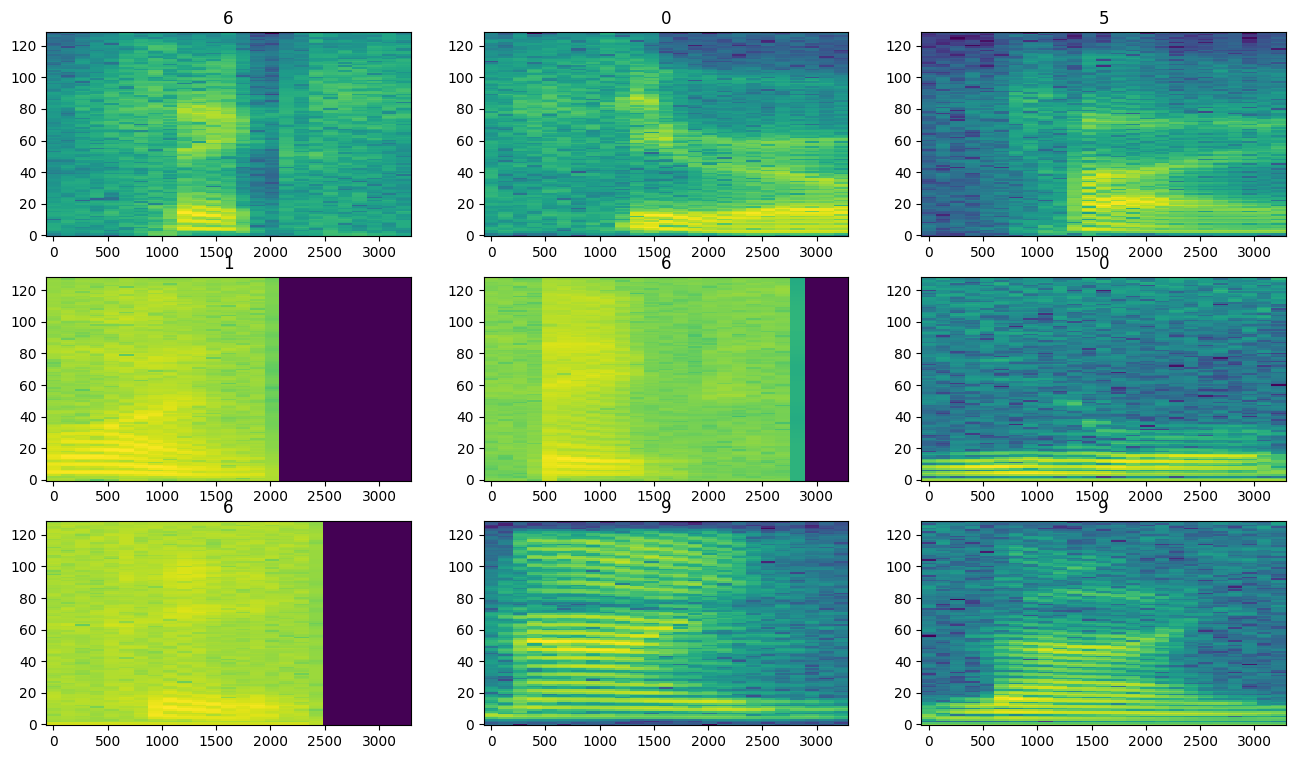

In [18]:
rows = 3
cols = 3
n = rows*cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 9))

for i in range(n):
    r = i // cols
    c = i % cols
    ax = axes[r][c]
    plot_spectrogram(example_spectrograms[i].numpy(), ax)
    ax.set_title(label_names[example_spect_labels[i].numpy()])

plt.show()

Visualizamos que cada numero ostenta un patrón distinto. También podemos remarcar que hay audios que tienen padding.

# CNN

Para implementar la red convolucional, se reforma el dataset a imagenes de espectogramas.

In [19]:
train_spectrogram_ds = train_spectrogram_ds.cache().shuffle(10000).prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)

Creación de la red neuronal.

In [20]:
input_shape = example_spectrograms.shape[1:]
print('Input shape:', input_shape)
num_labels = len(label_names)

# Instantiate the `tf.keras.layers.Normalization` layer.
norm_layer = layers.Normalization()
# Fit the state of the layer to the spectrograms
# with `Normalization.adapt`.
norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))

model = models.Sequential([
    layers.Input(shape=input_shape),
    # Downsample the input.
    layers.Resizing(32, 32),
    # Normalize.
    norm_layer,
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels),
])

model.summary()

Input shape: (25, 129, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 32, 32, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,869 (6.20 MB)

 Trainable params: 1,625,866 (6.20 MB)

 Non-trainable params: 3 (16.00 B)

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

In [22]:
EPOCHS = 50

history = model.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    callbacks=tf.keras.callbacks.EarlyStopping(verbose=1, patience=5),
)

Epoch 1/50


I0000 00:00:1751233792.253598    1921 service.cc:152] XLA service 0x7982f001c7d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751233792.253660    1921 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-06-29 21:49:52.324133: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1751233792.974221    1921 cuda_dnn.cc:529] Loaded cuDNN version 90300


 3/75 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.1389 - loss: 2.3011  

I0000 00:00:1751233802.746807    1921 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


74/75 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3365 - loss: 1.9266

2025-06-29 21:50:05.174779: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_193', 4 bytes spill stores, 4 bytes spill loads

2025-06-29 21:50:07.803333: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_193', 4 bytes spill stores, 4 bytes spill loads



75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 95ms/step - accuracy: 0.3397 - loss: 1.9186 - val_accuracy: 0.7367 - val_loss: 0.9488
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6623 - loss: 1.0122 - val_accuracy: 0.8417 - val_loss: 0.5518
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7851 - loss: 0.6501 - val_accuracy: 0.8717 - val_loss: 0.4245
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8389 - loss: 0.4919 - val_accuracy: 0.9200 - val_loss: 0.2937
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8801 - loss: 0.3613 - val_accuracy: 0.9183 - val_loss: 0.2635
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9131 - loss: 0.2645 - val_accuracy: 0.9233 - val_loss: 0.2553
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9169 - loss: 0.2614 - val_accuracy: 0.9400 - val_loss: 0.2055
Epoch 8/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9380 - loss: 0.2098 - val_accuracy: 0.9533 - val_loss: 0

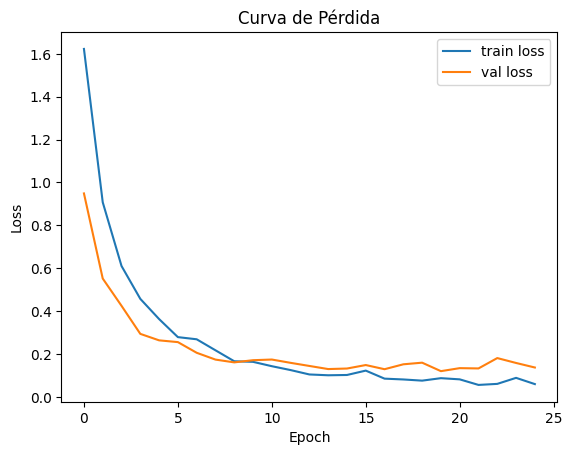

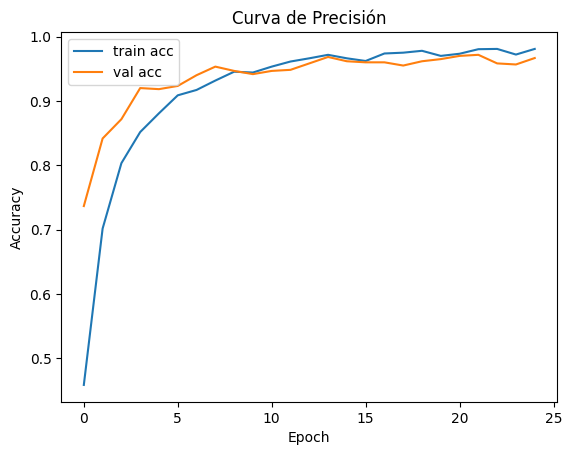

In [23]:
plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curva de Pérdida')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Curva de Precisión')
plt.legend()
plt.show()

final_train_loss = history.history['loss'][-1]
final_val_loss   = history.history['val_loss'][-1]
final_train_acc  = history.history['accuracy'][-1]
final_val_acc    = history.history['val_accuracy'][-1]

In [24]:
print(f"Final Train → Loss: {final_train_loss:.4f}   Accuracy: {final_train_acc:.4f}")
print(f"Final Val   → Loss: {final_val_loss:.4f}   Accuracy: {final_val_acc:.4f}")

Final Train → Loss: 0.0594   Accuracy: 0.9808
Final Val   → Loss: 0.1368   Accuracy: 0.9667


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


2025-06-29 21:50:45.728809: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


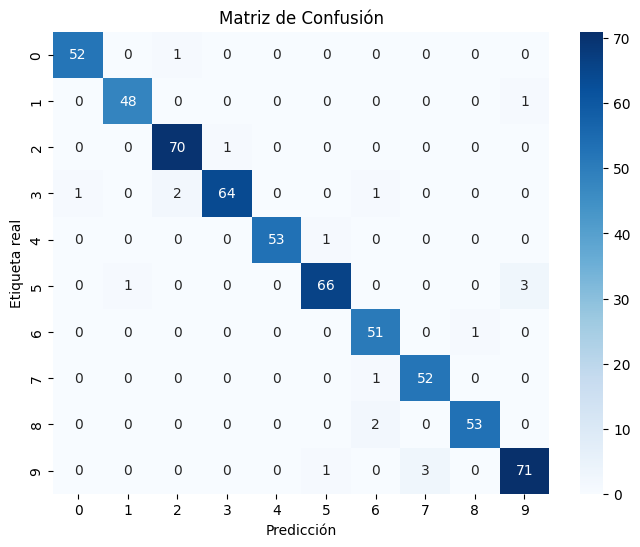


-------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       0.98      0.98      0.98        49
           2       0.96      0.99      0.97        71
           3       0.98      0.94      0.96        68
           4       1.00      0.98      0.99        54
           5       0.97      0.94      0.96        70
           6       0.93      0.98      0.95        52
           7       0.95      0.98      0.96        53
           8       0.98      0.96      0.97        55
           9       0.95      0.95      0.95        75

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600

-------------------------------------------


In [25]:
# Obtener las verdaderas etiquetas y las predicciones del modelo
y_true = []
y_pred = []

for audio_batch, label_batch in val_spectrogram_ds:
    # Predicciones del modelo (logits o probabilidades)
    predictions = model.predict(audio_batch)
    
    # Convertir a índice de clase si es one-hot o logits
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = label_batch.numpy()  # asumiendo que las etiquetas no están one-hot

    y_pred.extend(predicted_labels)
    y_true.extend(true_labels)

# Convertir a arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

def show_confusion_matrix(y_pred: np.ndarray, y_true: np.ndarray, class_names: list[str]) -> None:
    """
    Grafica la matriz de confusión y muestra el classification report.

    Args:
        y_pred (np.ndarray): Predicciones del modelo (índices de clase)
        y_true (np.ndarray): Etiquetas reales (índices de clase)
        class_names (list): Lista de nombres de clases
    """
    # Calcular la matriz de confusión
    confusion_mtx = tf.math.confusion_matrix(y_true, y_pred).numpy()

    # Graficar
    plt.figure(figsize=(8, 6))
    plt.title("Matriz de Confusión")
    sns.heatmap(confusion_mtx, xticklabels=class_names, yticklabels=class_names,
                annot=True, fmt='g', cmap="Blues")
    plt.xlabel('Predicción')
    plt.ylabel('Etiqueta real')
    plt.show()

    # Mostrar classification report
    print("\n-------------------------------------------")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    print("-------------------------------------------")


show_confusion_matrix(y_pred, y_true, label_names)

Podemos ver que las métricas en todos los casos son excelentes. Aquí podemos apreciar que diferencia las clases casi de forma perfecta. Tanto F1 como Recall ilustran esto.

In [26]:
model.save('models/cnn.keras')

# LSTM

In [27]:
BATCH_SIZE = 32
EPOCHS = 100
SR = 16000
N_MEL_BINS = 64
FRAME_LENGTH = 256
FRAME_STEP = 128
EPS = 1e-6

def create_lstm(input_shape, num_labels):
    """
    Crea un modelo LSTM bidireccional para clasificación de secuencias MFCC.

    Parámetros
    ----------
    input_shape : tuple de int
        Forma de la entrada por ejemplo (timesteps, 13), que coincide con
        la salida de waveform_to_mfcc para cada muestra.
    num_labels : int
        Número de clases de salida (tamaño del vocabulario de etiquetas).

    Devuelve
    -------
    model : tf.keras.Model
        Modelo compilado listo para entrenar con loss
        'sparse_categorical_crossentropy' y métrica 'accuracy'.
    """
    
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Bidirectional(layers.LSTM(64)),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(num_labels, activation='softmax')
    ])
    
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

def waveform_to_mfcc(waveform, label):
    """
    Convierte lotes de forma de onda en su representación MFCC normalizada.

    Parámetros
    ----------
    waveform : tf.Tensor
        Tensor de tipo float32 con forma [batch_size, seq_length, 1],
        donde `seq_length` == output_sequence_length definido en
        audio_dataset_from_directory. Cada valor está en [-1.0, +1.0].
    label : tf.Tensor
        Tensor de enteros con forma [batch_size], la etiqueta
        de clase para cada ejemplo de audio.

    Devuelve
    -------
    mfccs : tf.Tensor
        Tensor float32 con forma [batch_size, timesteps, 13], donde
        `timesteps = 1 + (seq_length - FRAME_LENGTH) // FRAME_STEP`.
        Son los 13 primeros coeficientes MFCC, normalizados en
        media 0 y desviación estándar 1 a lo largo del eje temporal.
    label : tf.Tensor
        Mismas etiquetas de entrada, sin modificar.
    """
    waveform = tf.squeeze(waveform, axis=-1)

    # STFT → espectrograma
    spec = tf.signal.stft(
        waveform,
        frame_length=FRAME_LENGTH,
        frame_step=FRAME_STEP
    )
    spec = tf.abs(spec) 

    mel_matrix = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=N_MEL_BINS,
        num_spectrogram_bins=spec.shape[-1],
        sample_rate=SR
    )
    mel_spec = tf.tensordot(spec, mel_matrix, axes=1)  

    log_mel = tf.math.log(mel_spec + EPS)
    mfccs = tf.signal.mfccs_from_log_mel_spectrograms(log_mel)[..., :13] 

    # Normalizar cada coeficiente a lo largo del eje temporal
    mean = tf.reduce_mean(mfccs, axis=1, keepdims=True)
    std  = tf.math.reduce_std(mfccs, axis=1, keepdims=True)
    mfccs = (mfccs - mean) / (std + EPS)

    return mfccs, label


In [28]:
train_ds, val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory=ORGANIZED_DATA_PATH,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    seed=SEED,
    output_sequence_length=SEQUENCE_LENGTH,
    subset='both',
)

train_ds = (
    train_ds
    .map(waveform_to_mfcc, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(1000)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .map(waveform_to_mfcc, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)


for x_batch, y_batch in train_ds.take(1):
    input_shape = x_batch.shape[1:]
    num_labels = int(tf.reduce_max(y_batch).numpy()) + 1
    break

model = create_lstm(input_shape, num_labels)
model.summary()

Found 3000 files belonging to 10 classes.
Using 2400 files for training.
Using 600 files for validation.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 25, 128)        │        39,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 25, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,938 (581.79 KB)

 Trainable params: 148,298 (579.29 KB)

 Non-trainable params: 640 (2.50 KB)

In [29]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.1015 - loss: 3.5147 - val_accuracy: 0.2150 - val_loss: 2.2202
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.1681 - loss: 2.9915 - val_accuracy: 0.2900 - val_loss: 2.0386
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.2513 - loss: 2.6549 - val_accuracy: 0.4233 - val_loss: 1.7388
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.2970 - loss: 2.2955 - val_accuracy: 0.5433 - val_loss: 1.4533
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.3257 - loss: 2.1306 - val_accuracy: 0.5933 - val_loss: 1.2397
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.3627 - loss: 1.9274 - val_accuracy: 0.6250 - val_loss: 1.0972
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.3877 - loss: 1.9230 - val_accuracy: 0.6767 - val_loss: 0.9919
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.4362 - loss: 1.7232 - val_accuracy: 0

In [30]:
model.save("models/lstm.keras")

In [31]:
train_loss, train_acc = model.evaluate(
    train_ds,
    verbose=1
)
print(f"Train -> Loss: {train_loss:.4f}   Accuracy: {train_acc:.4f}")

val_loss, val_acc = model.evaluate(
    val_ds,
    verbose=1
)
print(f"Val. -> Loss: {val_loss:.4f}   Accuracy: {val_acc:.4f}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9981 - loss: 0.0067
Train -> Loss: 0.0072   Accuracy: 0.9987
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9523 - loss: 0.1518
Val. -> Loss: 0.1293   Accuracy: 0.9583


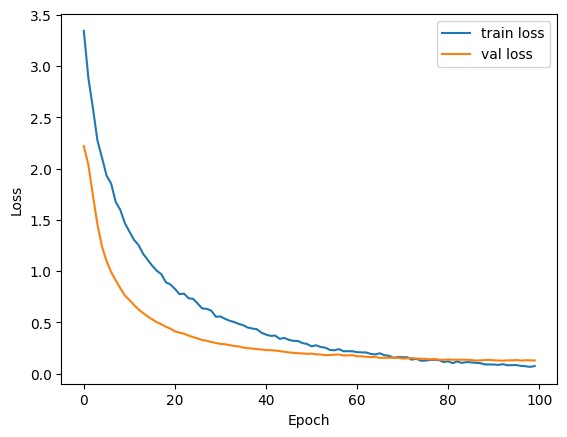

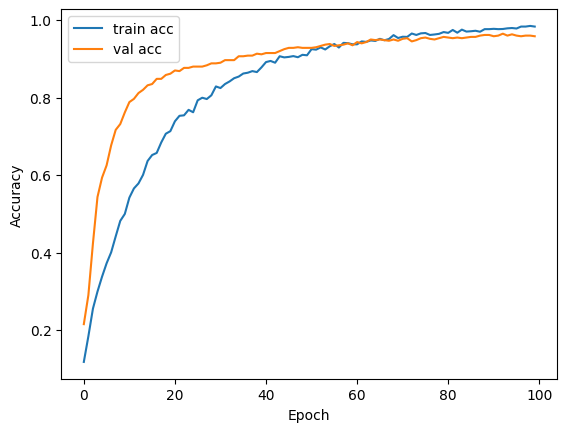

In [32]:
plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Informe y Análisis de Resultados

## 1. Descripción de los experimentos

Se compararon dos arquitecturas para la clasificación de audio:

* **CNN** (red convolucional sobre espectrogramas)  
* **RNN** (LSTM bidireccional sobre secuencias de MFCC)

Para cada modelo se entrenó durante un máximo de 100 épocas (con EarlyStopping de paciencia 5 en la CNN), evaluando en cada época la pérdida (`loss`) y la precisión (`accuracy`) en los conjuntos de entrenamiento y validación.

---

## 2. Curvas de pérdida

### 2.1. CNN

![Pérdida CNN](output/perdida_cnn.png)

* **Descenso rápido** durante las primeras 5–6 épocas.  
* **Estabilización** de la pérdida de validación en torno a 0.10–0.12 tras aplicar EarlyStopping (~época 20).  
* **Breves repuntes** de `val_loss` que sugieren algo de variabilidad, pero sin una tendencia clara de sobreajuste prematuro.

### 2.2. RNN

![Pérdida RNN](output/perdida_rnn.png)

* **Descenso más gradual** en comparación con la CNN, extendiéndose hasta cerca de la época 80.  
* La **pérdida de entrenamiento** baja más lentamente, indicando que la RNN requiere más épocas para ajustarse.  
* La **pérdida de validación** se estabiliza cerca de 0.12–0.14 alrededor de la época 80–90.

---

## 3. Curvas de precisión

### 3.1. CNN

![Precisión CNN](output/presicion_cnn.png)

* **Arranque rápido**: `val_accuracy` supera 0.85 en la época 3.  
* **Rápida convergencia** hacia 0.92–0.94 en las épocas 5–8.  
* **Mejora marginal** posterior, alcanzando pico de ~0.96 hacia la época 15–20 antes de detenerse.

### 3.2. RNN

![Precisión RNN](output/presicion_rnn.png)

* **Inicialmente baja** (~0.15) pero incrementa de forma continua.  
* **Se cruza con la CNN** alrededor de la época 30, cuando `train_accuracy` y `val_accuracy` superan 0.90.  
* **Convergencia lenta** hacia 0.98–0.99 a partir de la época 80, demostrando un potencial de precisión ligeramente superior al final.

---

## 4. Comparativa y conclusiones

| Métrica                     | CNN                    | RNN                       |
| --------------------------- | ---------------------- | ------------------------- |
| **Rápidez de convergencia** | Muy alta (5–8 épocas)  | Media–baja (30–80 épocas) |
| **Loss mínimo validación**  | ~0.10–0.12 (época 20)  | ~0.12–0.14 (época 80)     |
| **Accuracy validación**     | ~0.96 (época 15–20)    | ~0.99 (época 90–100)      |
| **Estabilidad**             | Pequeños repuntes      | Curvas suaves             |

1. **CNN**  
   * Ideal si se busca **rápida iteración** y menor tiempo de entrenamiento.  
   * Buen trade-off entre velocidad y precisión (~96 %).  
   * Menos sensible a overfitting gracias al EarlyStopping.

2. **RNN**  
   * Requiere **muchas más épocas** pero acaba logrando **ligeramente mayor precisión** (~99 %).  
   * Más estable en sus curvas de validación, sin repuntes bruscos.  
   * Útil si se dispone de mayor tiempo de cómputo y se quiere exprimir al máximo el performance.  
